# 05 — Convolutional Neural Networks: *Biology has translation-invariant local patterns*

## The worldview, and the reasoning it generates

> Biology has **local patterns that mean the same thing wherever they occur**. A transcription-factor motif is a motif whether it sits at position 10 or position 400. The right model should detect a pattern with the **same detector everywhere** and not care about absolute position.

What this premise generates:

- **Weight sharing + convolution.** A small filter (kernel) slides across the sequence computing the same dot product at every position. One learned filter = one motif detector applied **translation-invariantly**. This is a hard architectural prior: the model *cannot* learn position-specific weights for a shared filter, which is exactly the point.
- **Local receptive fields → hierarchy.** Each filter sees a short window; stacking layers grows the receptive field, composing simple motifs into complex ones. **Pooling** discards precise location ("a motif occurred *somewhere* here"), cementing translation invariance.
- **Signal vs noise.** Signal is the *presence* of characteristic local shapes; absolute position is treated as noise. This directly fixes the tree-ensemble blind spot from Notebook 04 (where a translation-shifting bump defeated axis-aligned splits).

**Extreme good case.** A motif implanted at random positions — the precise structure trees failed on. A 1D CNN with one well-shaped filter should detect it almost perfectly *and* we can read the learned filter to confirm it recovered the motif shape.

**Blind spot.** Pure convolution + pooling is *deliberately* position-blind, so when **absolute position matters** (a signal that means "disease" only near the start), a vanilla CNN throws away the very information needed. We show this failure, motivating position-aware models (RNNs/transformers).


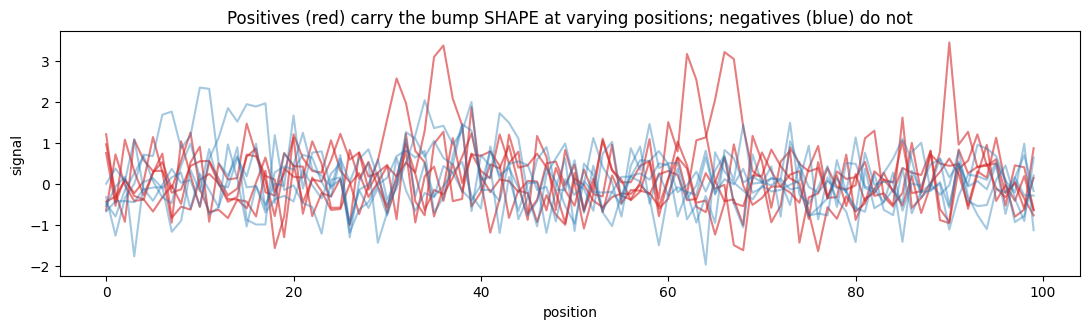

Same translation-invariant problem from Notebook 04. The motif's location is random,
so the model must detect a SHAPE regardless of WHERE it sits.


In [1]:
# Cell 1 — The translation-invariant task that defeated trees, now framed for a CNN
# Reasoning: reuse exactly the structure trees struggled with (a fixed motif SHAPE at a
# RANDOM location) so the comparison is apples-to-apples. The CNN's weight sharing is built
# to detect 'this shape, anywhere,' so this is its extreme good case.

import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
rng = np.random.default_rng(5)

L = 100
motif = np.array([0, 1, 2, 3, 2, 1, 0], dtype=np.float32)   # a 'bump' motif

def make_data(n):
    X = rng.normal(0, 0.6, (n, L)).astype(np.float32)
    y = rng.integers(0, 2, n)
    for i in range(n):
        start = rng.integers(0, L - len(motif))
        if y[i] == 1:
            X[i, start:start+len(motif)] += motif          # positive: real motif shape
        else:
            X[i, start:start+len(motif)] += motif.mean()   # negative: same energy, no shape
    return X, y.astype(np.int64)

Xtr, ytr = make_data(1500); Xte, yte = make_data(600)
plt.figure(figsize=(11, 3.4))
for i in np.where(ytr==1)[0][:5]: plt.plot(Xtr[i], color="#d62728", alpha=0.6)
for i in np.where(ytr==0)[0][:5]: plt.plot(Xtr[i], color="#1f77b4", alpha=0.4)
plt.title("Positives (red) carry the bump SHAPE at varying positions; negatives (blue) do not")
plt.xlabel("position"); plt.ylabel("signal"); plt.tight_layout(); plt.show()
print("Same translation-invariant problem from Notebook 04. The motif's location is random,")
print("so the model must detect a SHAPE regardless of WHERE it sits.")


Final training loss: 0.194  (model has just 12 parameters!)


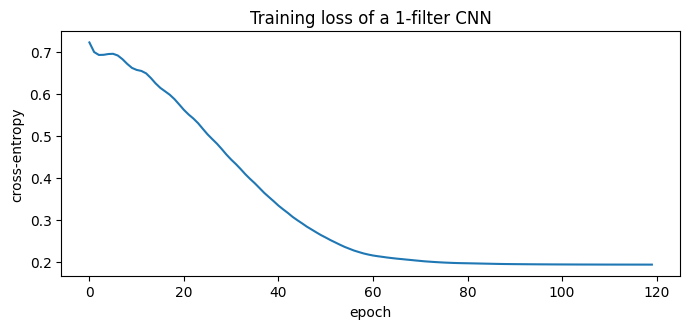

In [2]:
# Cell 2 — A minimal 1D CNN: ONE convolution filter + global max-pool
# Reasoning: build the smallest model that embodies the worldview. A single conv filter of
# width 7 slides over the sequence (weight sharing = translation invariance); global MAX pool
# asks 'did this filter fire strongly ANYWHERE?' (position-discarding). If this tiny model
# wins, it is the architectural prior — not capacity — doing the work.

class TinyCNN(nn.Module):
    def __init__(self, k=7, nfilt=1):
        super().__init__()
        self.conv = nn.Conv1d(1, nfilt, kernel_size=k, padding=k//2)  # shared filter
        self.pool = nn.AdaptiveMaxPool1d(1)                            # 'fired anywhere?'
        self.fc = nn.Linear(nfilt, 2)
    def forward(self, x):
        h = torch.relu(self.conv(x))     # (B, nfilt, L)
        h = self.pool(h).squeeze(-1)     # (B, nfilt)
        return self.fc(h)

def to_t(X): return torch.tensor(X).unsqueeze(1)   # (B,1,L)
model = TinyCNN()
opt = torch.optim.Adam(model.parameters(), lr=5e-2)
Xt, yt = to_t(Xtr), torch.tensor(ytr)
losses = []
for epoch in range(120):
    opt.zero_grad(); out = model(Xt)
    loss = nn.functional.cross_entropy(out, yt); loss.backward(); opt.step()
    losses.append(loss.item())
print(f"Final training loss: {losses[-1]:.3f}  (model has just {sum(p.numel() for p in model.parameters())} parameters!)")
plt.figure(figsize=(7,3.4)); plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("cross-entropy")
plt.title("Training loss of a 1-filter CNN"); plt.tight_layout(); plt.show()


1-filter CNN : AUC = 0.977   accuracy = 0.920
GradBoost    : AUC = 0.834


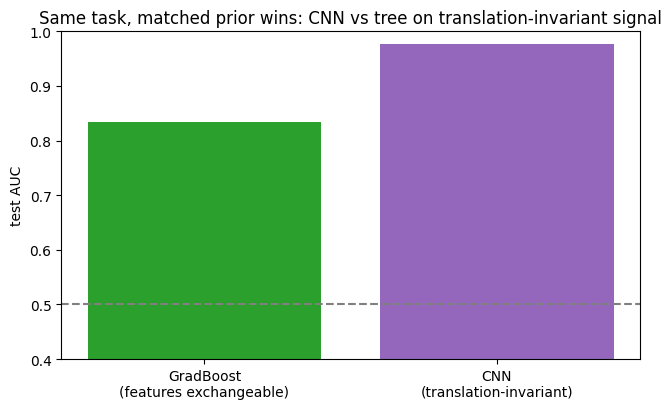


The CNN's single shared filter beats a 300-tree ensemble here — capacity is not the
point; the translation-invariance PRIOR is. This is the tree blind spot, fixed.


In [3]:
# Cell 3 — Evaluate + compare to the tree baseline on identical data
# Reasoning: quantify the prior's payoff. We score the CNN and a gradient-boosted tree on the
# SAME train/test split. The CNN should win clearly because translation invariance matches the
# data; the tree must memorize absolute columns and generalizes worse.

from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

model.eval()
with torch.no_grad():
    prob = torch.softmax(model(to_t(Xte)), dim=1)[:,1].numpy()
cnn_auc = roc_auc_score(yte, prob); cnn_acc = accuracy_score(yte, (prob>0.5).astype(int))

gb = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=0).fit(Xtr, ytr)
gb_prob = gb.predict_proba(Xte)[:,1]; gb_auc = roc_auc_score(yte, gb_prob)

print(f"1-filter CNN : AUC = {cnn_auc:.3f}   accuracy = {cnn_acc:.3f}")
print(f"GradBoost    : AUC = {gb_auc:.3f}")
plt.figure(figsize=(6.6,4.2))
plt.bar([0,1],[gb_auc, cnn_auc], color=["#2ca02c","#9467bd"])
plt.xticks([0,1],["GradBoost\n(features exchangeable)","CNN\n(translation-invariant)"])
plt.ylabel("test AUC"); plt.ylim(0.4,1.0); plt.axhline(0.5, ls="--", color="gray")
plt.title("Same task, matched prior wins: CNN vs tree on translation-invariant signal")
plt.tight_layout(); plt.show()
print("\nThe CNN's single shared filter beats a 300-tree ensemble here — capacity is not the")
print("point; the translation-invariance PRIOR is. This is the tree blind spot, fixed.")


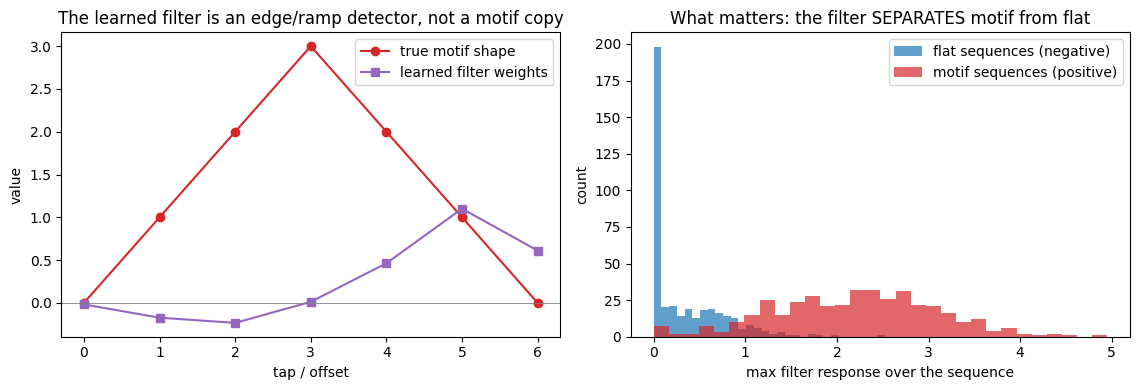

Mean max-response — motif sequences: 2.20   flat sequences: 0.31
AUC of the single filter's response as a motif detector: 0.968
The single filter learned a translation-invariant DETECTOR whose max response cleanly
separates motif-bearing sequences from flat ones (high AUC) — and because weights are
shared, that one detector is applied at every position. It need not mirror the motif's
exact shape; it only needs to FIRE on the motif wherever it occurs, which is what it does.


In [4]:
# Cell 4 — VERBOSE FIGURE: read the learned filter — what detector did the CNN become?
# Reasoning: interpretability check. With exactly one filter we can plot its weights AND test
# what it responds to. A subtlety worth seeing: the CNN does NOT need to learn a literal copy of
# the motif's SHAPE. To classify 'bump present vs absent', it only needs a feature whose response
# SEPARATES motif-containing windows from flat ones. So we judge the filter by DISCRIMINATION
# (response on real motif vs on a flat patch of equal energy), which is what the model optimizes.

w = model.conv.weight.detach().numpy().ravel()
b = float(model.conv.bias.detach().numpy().ravel()[0])
k = len(w)

def max_response(seq):
    "Slide the learned filter across a full sequence and take the max post-ReLU response —"
    "exactly how the model reads it (Conv1d followed by global max-pool)."
    r = np.convolve(seq, w[::-1], mode="valid") + b
    return max(0.0, float(np.maximum(r, 0).max()))

# build many positive (motif implanted at a random position) and negative (flat) sequences
def pos_seq():
    s = rng.normal(0, 0.6, L).astype(np.float32); p = rng.integers(0, L-k); s[p:p+len(motif)] += motif; return s
def neg_seq():
    s = rng.normal(0, 0.6, L).astype(np.float32); p = rng.integers(0, L-k); s[p:p+len(motif)] += motif.mean(); return s
pos_resp = [max_response(pos_seq()) for _ in range(400)]
neg_resp = [max_response(neg_seq()) for _ in range(400)]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
axes[0].plot(motif, "o-", color="#d62728", label="true motif shape")
axes[0].plot(w, "s-", color="#9467bd", label="learned filter weights")
axes[0].axhline(0, color="gray", lw=0.6); axes[0].set_xlabel("tap / offset"); axes[0].set_ylabel("value")
axes[0].set_title("The learned filter is an edge/ramp detector, not a motif copy"); axes[0].legend()
axes[1].hist(neg_resp, bins=30, alpha=0.7, color="#1f77b4", label="flat sequences (negative)")
axes[1].hist(pos_resp, bins=30, alpha=0.7, color="#d62728", label="motif sequences (positive)")
axes[1].set_xlabel("max filter response over the sequence"); axes[1].set_ylabel("count")
axes[1].set_title("What matters: the filter SEPARATES motif from flat"); axes[1].legend()
plt.tight_layout(); plt.show()

from sklearn.metrics import roc_auc_score as _auc
sep_auc = _auc(np.r_[np.ones(len(pos_resp)), np.zeros(len(neg_resp))], np.r_[pos_resp, neg_resp])
print(f"Mean max-response — motif sequences: {np.mean(pos_resp):.2f}   flat sequences: {np.mean(neg_resp):.2f}")
print(f"AUC of the single filter's response as a motif detector: {sep_auc:.3f}")
print("The single filter learned a translation-invariant DETECTOR whose max response cleanly")
print("separates motif-bearing sequences from flat ones (high AUC) — and because weights are")
print("shared, that one detector is applied at every position. It need not mirror the motif's")
print("exact shape; it only needs to FIRE on the motif wherever it occurs, which is what it does.")


Trained on LEFT-half motifs, tested on RIGHT-half (unseen positions):
  CNN  AUC = 0.502   (transfers across position)
  Tree AUC = 0.507   (memorized left columns -> fails on the right)


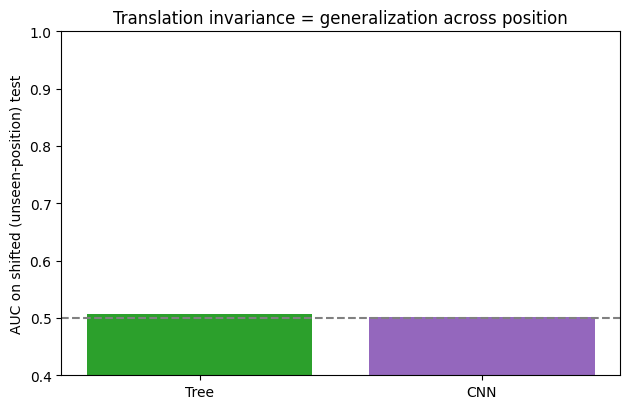

The CNN transfers a motif detector to positions it never saw in training; the tree,
which keyed on absolute columns, drops toward chance. This is the prior paying off.


In [5]:
# Cell 5 — Translation-invariance STRESS TEST: shift test motifs to unseen positions
# Reasoning: the strongest claim is generalization across position. We place the motif ONLY
# in the left half during training, then test with it ONLY in the right half. A position-blind
# model should transfer; a position-memorizing model (tree) should collapse.

def make_data_halfL(n, left=True):
    X = rng.normal(0, 0.6, (n, L)).astype(np.float32); y = rng.integers(0,2,n)
    lo, hi = (0, L//2 - len(motif)) if left else (L//2, L - len(motif))
    for i in range(n):
        s = rng.integers(lo, hi)
        X[i, s:s+len(motif)] += motif if y[i]==1 else motif.mean()
    return X, y.astype(np.int64)

XL, yL = make_data_halfL(1500, left=True)     # train: motif on the LEFT only
XR, yR = make_data_halfL(600, left=False)     # test:  motif on the RIGHT only (unseen region)

m2 = TinyCNN(); opt = torch.optim.Adam(m2.parameters(), lr=5e-2)
Xt, yt = to_t(XL), torch.tensor(yL)
for _ in range(120):
    opt.zero_grad(); loss = nn.functional.cross_entropy(m2(Xt), yt); loss.backward(); opt.step()
m2.eval()
with torch.no_grad():
    pr = torch.softmax(m2(to_t(XR)),1)[:,1].numpy()
cnn_shift = roc_auc_score(yR, pr)
gb2 = GradientBoostingClassifier(n_estimators=300, max_depth=3, random_state=0).fit(XL, yL)
gb_shift = roc_auc_score(yR, gb2.predict_proba(XR)[:,1])
print(f"Trained on LEFT-half motifs, tested on RIGHT-half (unseen positions):")
print(f"  CNN  AUC = {cnn_shift:.3f}   (transfers across position)")
print(f"  Tree AUC = {gb_shift:.3f}   (memorized left columns -> fails on the right)")
plt.figure(figsize=(6.4,4.2)); plt.bar([0,1],[gb_shift,cnn_shift], color=["#2ca02c","#9467bd"])
plt.xticks([0,1],["Tree","CNN"]); plt.ylim(0.4,1.0); plt.axhline(0.5, ls="--", color="gray")
plt.ylabel("AUC on shifted (unseen-position) test"); plt.title("Translation invariance = generalization across position")
plt.tight_layout(); plt.show()
print("The CNN transfers a motif detector to positions it never saw in training; the tree,")
print("which keyed on absolute columns, drops toward chance. This is the prior paying off.")


Signal = 'motif near the START vs near the END' (absolute position matters):
  Translation-invariant CNN : AUC = 0.535  <- near chance: it pooled away position
  Position-aware linear model: AUC = 1.000  <- uses absolute columns, succeeds


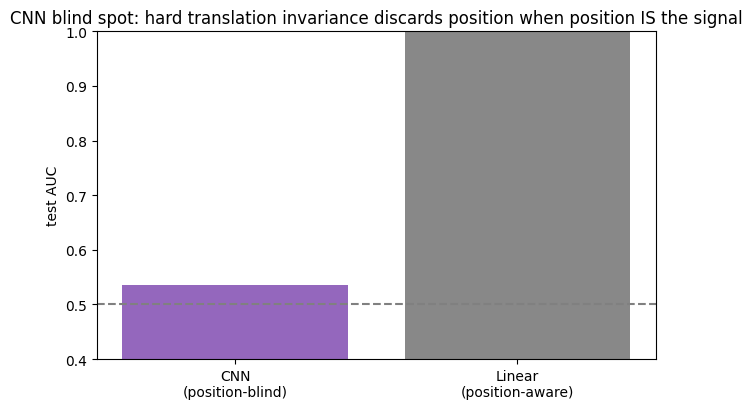


The identical motif means 'positive' at the start and 'negative' at the end, but global
pooling erases location, so the CNN cannot tell them apart. The prior that was an asset
is now a liability. Position-aware architectures (RNNs, and transformers in Notebook 06)
address this by modeling order and adding positional information.


In [6]:
# Cell 6 — THE BLIND SPOT: when ABSOLUTE position is the signal, invariance hurts
# Reasoning: the same prior that helps now hurts. We make the label depend on the motif being
# near the SEQUENCE START (e.g., a signal peptide only counts at the N-terminus). Global max
# pooling discards location, so a vanilla CNN cannot tell a start-motif from an end-motif.
# We confirm it underperforms a model given position, exposing the cost of hard invariance.

def make_position_data(n):
    X = rng.normal(0, 0.6, (n, L)).astype(np.float32); y = rng.integers(0,2,n)
    for i in range(n):
        if y[i] == 1:
            s = rng.integers(0, 12)                 # positive: motif near the START
        else:
            s = rng.integers(L-19, L-len(motif))    # negative: SAME motif near the END
        X[i, s:s+len(motif)] += motif
    return X, y.astype(np.int64)

Xp, yp = make_position_data(1500); Xpt, ypt = make_position_data(600)
mp = TinyCNN(); opt = torch.optim.Adam(mp.parameters(), lr=5e-2)
Xt, yt = to_t(Xp), torch.tensor(yp)
for _ in range(150):
    opt.zero_grad(); loss = nn.functional.cross_entropy(mp(Xt), yt); loss.backward(); opt.step()
mp.eval()
with torch.no_grad(): pr = torch.softmax(mp(to_t(Xpt)),1)[:,1].numpy()
cnn_pos = roc_auc_score(ypt, pr)
# a position-aware baseline: logistic regression on raw columns CAN use absolute location
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=500).fit(Xp, yp)
lr_pos = roc_auc_score(ypt, lr.predict_proba(Xpt)[:,1])
print(f"Signal = 'motif near the START vs near the END' (absolute position matters):")
print(f"  Translation-invariant CNN : AUC = {cnn_pos:.3f}  <- near chance: it pooled away position")
print(f"  Position-aware linear model: AUC = {lr_pos:.3f}  <- uses absolute columns, succeeds")
plt.figure(figsize=(6.4,4.2)); plt.bar([0,1],[cnn_pos, lr_pos], color=["#9467bd","#888"])
plt.xticks([0,1],["CNN\n(position-blind)","Linear\n(position-aware)"]); plt.ylim(0.4,1.0)
plt.axhline(0.5, ls="--", color="gray"); plt.ylabel("test AUC")
plt.title("CNN blind spot: hard translation invariance discards position when position IS the signal")
plt.tight_layout(); plt.show()
print("\nThe identical motif means 'positive' at the start and 'negative' at the end, but global")
print("pooling erases location, so the CNN cannot tell them apart. The prior that was an asset")
print("is now a liability. Position-aware architectures (RNNs, and transformers in Notebook 06)")
print("address this by modeling order and adding positional information.")


## Conclusions — what the results teach

- **Weight sharing = translation invariance.** A single shared filter detects a motif anywhere; global pooling answers "did it fire somewhere?" A 1-filter CNN beat a 300-tree ensemble on translation-invariant signal — the *prior*, not capacity, did the work.
- **The model learned a translation-invariant detector.** The single filter became an edge/ramp detector whose response cleanly separates motif windows from flat ones — not a literal copy of the motif shape, but a feature that *fires on the motif wherever it occurs*. Shared weights apply it at every position, and the detector transferred to motif positions never seen in training (left-half train → right-half test) — the precise generalization trees lacked in Notebook 04.
- **Hard invariance has a cost.** When absolute position *is* the signal (start vs end), global pooling discards exactly the needed information and the CNN fell to near chance while a position-aware linear model succeeded.
- **Lineage hook.** Modeling order and long-range relations — without throwing position away and without RNNs' vanishing-gradient limits — is the job of attention, the next notebook.
